# MCYSD-23 Machine Learning Optimization Lecture

A Jupyter notebook demonstrating concepts of machine learning optimization.
It covers GD, AdaGrad, RMSProp, Adam, Momentum, and compares some concepts to sklearn.
It discusses learning rate and hyperparameter tuning, and provides visualizations for comparisons and understanding of convergence and behaviours.

Group Members
- John P.
- Alvaro G. G.
- Chris D.

### Hello World

In [ ]:
print("Hello World!")

Hello World!


In [ ]:
from main import main
main()

Hello from ml-optimization-lecture!


In [ ]:
## Imports
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt

### Interactive function

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact, fixed
import inspect

def interactive_optimizer_plot(
    optimizer,
    gradient,
    loss_function,
    x_range=(-3, 3),
    zoom_on_points=True,
    zoom_margin=0.5,
    num_points=400,
    default_params=None,
    slider_config=None,
    title=None
):

    if default_params is None:
        default_params = {}

    if slider_config is None:
        slider_config = {}

    sig = inspect.signature(optimizer)
    params = sig.parameters

    candidate_controls = [
        "learning_rate",
        "num_iterations",
        "x_start",
        "beta",
        "beta1",
        "beta2",
    ]

    default_slider_settings = {
        "learning_rate": {"min": 0.001, "max": 2.0, "step": 0.001},
        "num_iterations": {"min": 1, "max": 100, "step": 1},
        "x_start": {"min": x_range[0], "max": x_range[1], "step": 0.1},
        "beta": {"min": 0.0, "max": 0.999, "step": 0.01},
        "beta1": {"min": 0.0, "max": 0.999, "step": 0.01},
        "beta2": {"min": 0.0, "max": 0.999, "step": 0.01},
    }

    controls = {}

    for name in candidate_controls:
        if name not in params:
            continue

        param = params[name]

        if name in default_params:
            value = default_params[name]
        elif param.default is not inspect._empty:
            value = param.default
        else:
            fallback = {
                "learning_rate": 0.1,
                "num_iterations": 30,
                "x_start": -2.0,
                "beta": 0.5,
                "beta1": 0.5,
                "beta2": 0.5,
            }
            value = fallback[name]

        cfg = default_slider_settings[name].copy()
        cfg.update(slider_config.get(name, {}))

        if name == "num_iterations":
            controls[name] = widgets.IntSlider(
                value=int(value),
                min=int(cfg["min"]),
                max=int(cfg["max"]),
                step=int(cfg["step"]),
                description=name,
                continuous_update=False
            )
        else:
            controls[name] = widgets.FloatSlider(
                value=float(value),
                min=float(cfg["min"]),
                max=float(cfg["max"]),
                step=float(cfg["step"]),
                description=name,
                readout_format=".3f",
                continuous_update=False
            )

    controls["gradient"] = fixed(gradient)
    controls["loss_function"] = fixed(loss_function)

    def _plot(**kwargs):
        positions, losses = optimizer(**kwargs)

        positions = np.asarray(positions)
        losses = np.asarray(losses)

        xs = np.linspace(x_range[0], x_range[1], num_points)
        ys = np.array([loss_function(x) for x in xs])

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        axes[0].plot(xs, ys)
        axes[0].scatter(positions, [loss_function(x) for x in positions], s=40)
        axes[0].plot(positions, [loss_function(x) for x in positions], linestyle="--", alpha=0.8)

        axes[0].set_title(title or f"Trajectory of {optimizer.__name__}")
        axes[0].set_xlabel("x")
        axes[0].set_ylabel("Loss")

        axes[1].plot(range(len(losses)), losses, marker="o")
        axes[1].set_title("Loss evolution")
        axes[1].set_xlabel("Iteration")
        axes[1].set_ylabel("Loss")

        if zoom_on_points:
            xmin, xmax = positions.min(), positions.max()
            axes[0].set_xlim(xmin - zoom_margin, xmax + zoom_margin)

            y_vals = [loss_function(x) for x in positions]
            ymin, ymax = min(y_vals), max(y_vals)
            axes[0].set_ylim(ymin - zoom_margin, ymax + zoom_margin)

        plt.tight_layout()
        plt.show()

    return interact(_plot, **controls)

### Example of loss with different learning rates

Learning rate is a crucial hyperparameter in optimization algorithms. It determines the step size at each iteration while moving toward a minimum of a loss function. Choosing an appropriate learning rate can significantly affect the convergence and performance of the model.

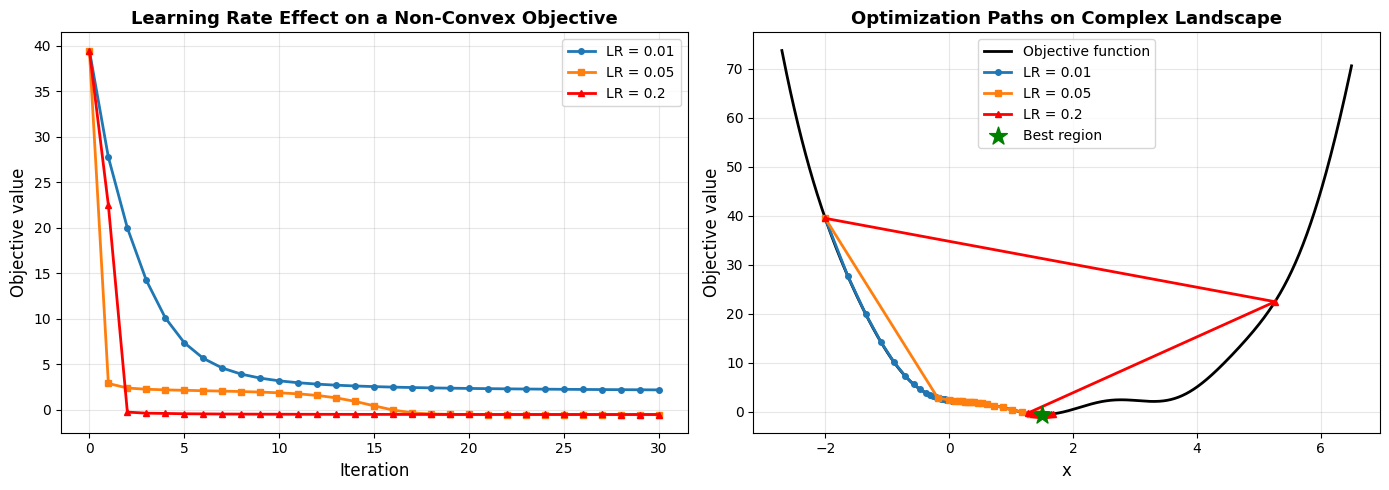

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Function: f(x) = 0.15*(x - 2)^4 + 1*sin(3x) + 0.2*x^2
def loss_function(x):
    return 0.15 * (x - 2) ** 4 + 1 * np.sin(3 * x) + 0.2 * x**2

# Derivative: f'(x) = 0.6*(x - 2)^3 + 3*cos(3x) + 0.4*x
def gradient(x):
    return 0.6 * (x - 2) ** 3 + 3 * np.cos(3 * x) + 0.4 * x


def gradient_descent(learning_rate, num_iterations=30, x_start=-2.0):
    x = x_start
    losses = [loss_function(x)]
    positions = [x]

    for _ in range(num_iterations):
        grad = gradient(x)
        x = x - learning_rate * grad
        losses.append(loss_function(x))
        positions.append(x)

    return positions, losses

# Learning rates
lr_low = 0.01
lr_medium = 0.05
lr_high = 0.20

positions_low, losses_low = gradient_descent(lr_low)
positions_medium, losses_medium = gradient_descent(lr_medium)
positions_high, losses_high = gradient_descent(lr_high)

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Objective value over iterations
iterations = range(len(losses_low))
axes[0].plot(iterations, losses_low, 'o-', label=f'LR = {lr_low}', linewidth=2, markersize=4)
axes[0].plot(iterations, losses_medium, 's-', label=f'LR = {lr_medium}', linewidth=2, markersize=4)
axes[0].plot(iterations, losses_high, '^-', label=f'LR = {lr_high}', linewidth=2, markersize=4, color='red')
axes[0].set_xlabel('Iteration', fontsize=12)
axes[0].set_ylabel('Objective value', fontsize=12)
axes[0].set_title('Learning Rate Effect on a Non-Convex Objective', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Optimization paths on the landscape
x_range = np.linspace(-2.7, 6.5, 600)
y_range = loss_function(x_range)
axes[1].plot(x_range, y_range, 'k-', linewidth=2, label='Objective function')
axes[1].plot(positions_low, losses_low, 'o-', label=f'LR = {lr_low}', linewidth=2, markersize=4)
axes[1].plot(positions_medium, losses_medium, 's-', label=f'LR = {lr_medium}', linewidth=2, markersize=4)
axes[1].plot(positions_high, losses_high, '^-', label=f'LR = {lr_high}', linewidth=2, markersize=4, color='red')

best_idx = np.argmin(y_range) # Mark an optimal value
axes[1].scatter([x_range[best_idx]], [y_range[best_idx]], color='green', s=180, marker='*', label='Best region', zorder=5)

axes[1].set_xlabel('x', fontsize=12)
axes[1].set_ylabel('Objective value', fontsize=12)
axes[1].set_title('Optimization Paths on Complex Landscape', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Questions
1. In a simple example, which one converges the slowest?
2. Why would a learning rate that is too high cause overshooting?
3. Why do they not all converge to the same point? Is it possible for each to converge to a different point?
4. Which one converges the fastest? Is this guaranteed to always be the case?

### Gradient Descent

In gradient descent, you try to minimize a function $L$ by using the gradient $\nabla L$ to follow the *steepness* of the function. As such, you repeat the following iteration:
$$\begin{align*}
    g_t &= \nabla L(w_t)\\[5pt]
    w_{t+1} &= w_t - \eta g_t
\end{align*}$$
where $\eta$ is the learning rate.

In [ ]:
def gradient_descent(learning_rate, num_iterations=30, x_start=-2.0, gradient=gradient, loss_function=loss_function):
    x = x_start
    losses = [loss_function(x)]
    positions = [x]

    for _ in range(num_iterations):
        grad = gradient(x)
        x = x - learning_rate * grad
        losses.append(loss_function(x))
        positions.append(x)

    return positions, losses

### AdaGrad

AdaGrad improves on regular gradient descent by having an adaptive learning rate, which leads to large steps for a low gradient (exploration), and small steps for a large gradient (exploitation). For this, you introduce $v_t$, which is the cumulative sum of all previous gradients squared.
$$\begin{align*}
    v_0 &= 0\\
    v_t &= v_{t-1} + g_t^2\\[2pt]
    w_{t+1} &= w_t - \frac{\eta}{\sqrt{v_t}+\epsilon} \cdot g_t
\end{align*}$$
where $\epsilon$ is a small value to avoid division by 0.

In [ ]:
def ada_grad(learning_rate, num_iterations=30, x_start=-2.0, gradient=gradient, loss_function=loss_function):
    eps = 1e-16
    x = x_start
    losses = [loss_function(x)]
    positions = [x]
    vt = 0
    for _ in range(num_iterations):
        grad = gradient(x)
        vt += grad**2
        x = x - learning_rate * grad / (sqrt(vt) + eps)
        losses.append(loss_function(x))
        positions.append(x)

    return positions, losses

### RMSProp

In AdaGrad, $v_t$ is constantly growing. This can lead to a very small learning value, so the progress each round becomes minimal for high learning rates. RMSProp avoids this by using a moving average. For this, we introduce an additional parameter $\beta$, which defines the importance of the accumulated averages versus the current gradient.
$$\begin{align*}
    v_0 &= 0\\[2pt]
    v_t &= \beta v_{t-1} + (1-\beta) g_t^2\\[5pt]
    \hat{v}_t &= \frac{v_t}{1-\beta^t}\\
    w_{t+1} &= w_t - \frac{\eta}{\sqrt{\hat{v}_t}+\epsilon} \cdot g_t
\end{align*}$$
$\hat{v}_t$ is used to offset the bias created by the initial choice $v_0 = 0$.

In [ ]:
def RMSProp(learning_rate, num_iterations=30, x_start=-2.0, beta=0.5, gradient=gradient, loss_function=loss_function):
    eps = 1e-16
    x = x_start
    losses = [loss_function(x)]
    positions = [x]
    vt = 0
    for t in range(1, num_iterations + 1):
        grad = gradient(x)
        vt = beta * vt + (1-beta) * grad**2
        vt_bias = vt / (1-beta**t)
        x = x - learning_rate * grad / (sqrt(vt_bias) + eps)
        losses.append(loss_function(x))
        positions.append(x)

    return positions, losses

### Momentum

Momentum takes a different approach from the previous versions by adding *momentum*. If we keep moving downhill in one direct, we "speed up" and take bigger steps. If we then hit a spot that descends in the opposite direction, we decelarate. In this case, the step size decreases, but the direction only changes if the slope of the point we hit is large enough.
$$\begin{align*}
    m_0 &= 0\\[2pt]
    m_t &= \beta m_{t-1} + (1-\beta) g_t\\[5pt]
    \hat{m}_t &= \frac{m_t}{1-\beta^t}\\
    w_{t+1} &= w_t - \eta\cdot\hat{m}_t
\end{align*}$$
$\hat{m}_t$ is used to offset the bias created by the initial choice $m_0 = 0$.\
Note that the gradient is now no longer squared, so $m_t$ can be negative.

In [ ]:
def momentum(learning_rate, num_iterations=30, x_start=-2.0, beta=0.5,  gradient=gradient, loss_function=loss_function):
    x = x_start
    losses = [loss_function(x)]
    positions = [x]
    mt = 0
    for t in range(1, num_iterations + 1):
        grad = gradient(x)
        mt = beta * mt + (1-beta) * grad
        mt_bias = mt / (1-beta**t)
        x = x - learning_rate * mt_bias
        losses.append(loss_function(x))
        positions.append(x)

    return positions, losses

### Adam

Adam combines RMSProp and Momentum to get smooth gradient direction (from Momentum) and adaptive scaling (from RMSProp).
$$\begin{align*}
    m_0 &= 0\qquad\qquad v_0 = 0\\[2pt]
    m_t &= \beta_1 \cdot m_{t-1} + (1-\beta_1) \cdot g_t\;, \qquad \hat{m}_t = \frac{m_t}{1-\beta_1^t}\\[10pt]
    v_t &= \beta_2 v_{t-1} + (1-\beta_2) g_t^2\;, \qquad \qquad \hat{v}_t = \frac{v_t}{1-\beta_2^t}\\
    w_{t+1} &= w_t - \eta \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon}
\end{align*}$$

In [ ]:
def adam(learning_rate, num_iterations=30, x_start=-2.0, beta1=0.5, beta2=0.5, gradient=gradient, loss_function=loss_function):
    eps = 1e-16
    x = x_start
    losses = [loss_function(x)]
    positions = [x]
    mt = 0
    vt = 0
    for t in range(1, num_iterations + 1):
        grad = gradient(x)

        mt = beta1 * mt + (1-beta1) * grad
        mt_bias = mt / (1-beta1**t)

        vt = beta2 * vt + (1-beta2) * grad**2
        vt_bias = vt / (1-beta2**t)

        x = x  - learning_rate * mt_bias / (sqrt(vt_bias) + eps)
        losses.append(loss_function(x))
        positions.append(x)

    return positions, losses

### Hyperparameters

In [ ]:
def loss_function_for_test_hyperparameters(x):
    return x**2 + 0.5*np.sin(5*x)

def gradient_for_test_hyperparameters(x):
    return 2*x + 2.5*np.cos(5*x)

In [ ]:
interactive_optimizer_plot(
    optimizer=gradient_descent,
    gradient=gradient_for_test_hyperparameters,
    loss_function=loss_function_for_test_hyperparameters,
    x_range=(-3, 3),
    zoom_on_points=False,
    default_params={
        "learning_rate": 0.05,
        "num_iterations": 10,
        "x_start": 2.0
    },
    title="Gradient Descent"
)

interactive(children=(FloatSlider(value=0.05, continuous_update=False, description='learning_rate', max=2.0, m…

<function __main__.interactive_optimizer_plot.<locals>._plot(**kwargs)>

In [ ]:
interactive_optimizer_plot(
    optimizer=ada_grad,
    gradient=gradient_for_test_hyperparameters,
    loss_function=loss_function_for_test_hyperparameters,
    x_range=(-3, 3),
    zoom_on_points=False,
    default_params={
        "learning_rate": 0.05,
        "num_iterations": 10,
        "x_start": 2.0
    },
    title="AdaGrad"
)

interactive(children=(FloatSlider(value=0.05, continuous_update=False, description='learning_rate', max=2.0, m…

<function __main__.interactive_optimizer_plot.<locals>._plot(**kwargs)>

In [ ]:
interactive_optimizer_plot(
    optimizer=RMSProp,
    gradient=gradient_for_test_hyperparameters,
    loss_function=loss_function_for_test_hyperparameters,
    x_range=(-3, 3),
    zoom_on_points=False,
    default_params={
        "learning_rate": 0.05,
        "num_iterations": 10,
        "x_start": 2.0,
        "beta": 0.9
    },
    title="RMSProp"
)

interactive(children=(FloatSlider(value=0.05, continuous_update=False, description='learning_rate', max=2.0, m…

<function __main__.interactive_optimizer_plot.<locals>._plot(**kwargs)>

In [ ]:
interactive_optimizer_plot(
    optimizer=momentum,
    gradient=gradient_for_test_hyperparameters,
    loss_function=loss_function_for_test_hyperparameters,
    x_range=(-3, 3),
    zoom_on_points=False,
    default_params={
        "learning_rate": 0.05,
        "num_iterations": 10,
        "x_start": 2.0,
        "beta": 0.9
    },
    title="Momentum"
)

interactive(children=(FloatSlider(value=0.05, continuous_update=False, description='learning_rate', max=2.0, m…

<function __main__.interactive_optimizer_plot.<locals>._plot(**kwargs)>

In [ ]:
interactive_optimizer_plot(
    optimizer=adam,
    gradient=gradient_for_test_hyperparameters,
    loss_function=loss_function_for_test_hyperparameters,
    x_range=(-3, 3),
    zoom_on_points=True,
    default_params={
        "learning_rate": 0.05,
        "num_iterations": 10,
        "x_start": 2.0,
        "beta1": 0.9,
        "beta2": 0.999
    },
    title="Adam"
)

interactive(children=(FloatSlider(value=0.05, continuous_update=False, description='learning_rate', max=2.0, m…

<function __main__.interactive_optimizer_plot.<locals>._plot(**kwargs)>

### Test Comparison (Draft)

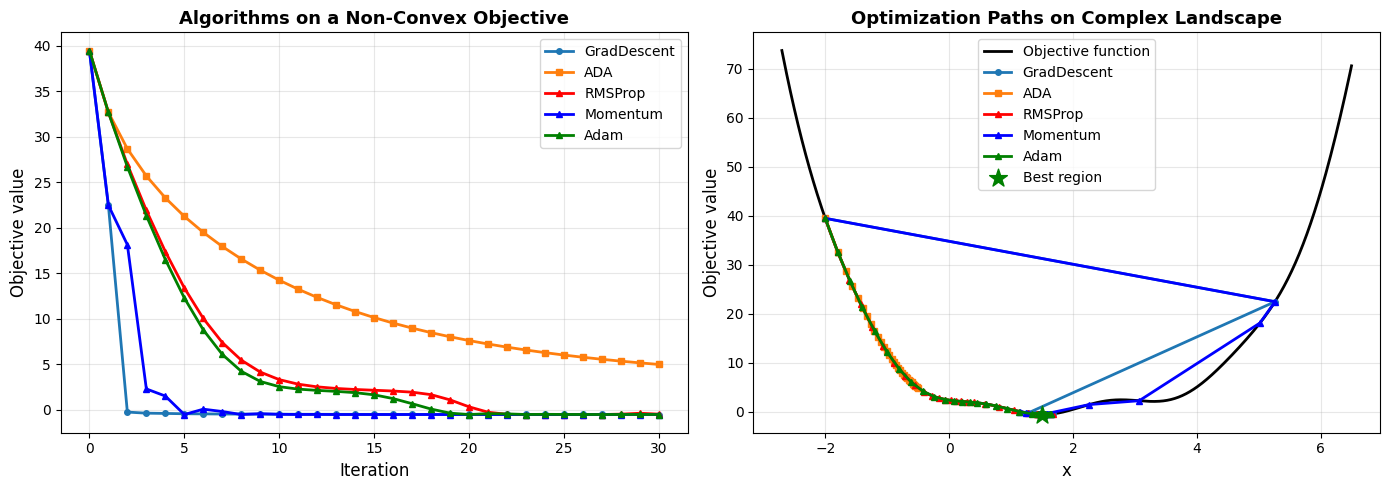

In [ ]:
# Learning rates
learning_rate = 0.2

positions_gd, losses_gd = gradient_descent(learning_rate)
positions_ada, losses_ada = ada_grad(learning_rate)
positions_rmsp, losses_rsmp = RMSProp(learning_rate)
positions_momentum, losses_momentum = momentum(learning_rate)
positions_adam, losses_adam = adam(learning_rate)

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Objective value over iterations
iterations = range(len(losses_gd))
axes[0].plot(iterations, losses_gd, 'o-', label=f'GradDescent', linewidth=2, markersize=4)
axes[0].plot(iterations, losses_ada, 's-', label=f'ADA', linewidth=2, markersize=4)
axes[0].plot(iterations, losses_rsmp, '^-', label=f'RMSProp', linewidth=2, markersize=4, color='red')
axes[0].plot(iterations, losses_momentum, '^-', label=f'Momentum', linewidth=2, markersize=4, color='blue')
axes[0].plot(iterations, losses_adam, '^-', label=f'Adam', linewidth=2, markersize=4, color='green')


axes[0].set_xlabel('Iteration', fontsize=12)
axes[0].set_ylabel('Objective value', fontsize=12)
axes[0].set_title('Algorithms on a Non-Convex Objective', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)


# Plot 2: Optimization paths on the landscape
x_range = np.linspace(-2.7, 6.5, 600)
y_range = loss_function(x_range)
axes[1].plot(x_range, y_range, 'k-', linewidth=2, label='Objective function')
axes[1].plot(positions_gd, losses_gd, 'o-', label=f'GradDescent', linewidth=2, markersize=4)
axes[1].plot(positions_ada, losses_ada, 's-', label=f'ADA', linewidth=2, markersize=4)
axes[1].plot(positions_rmsp, losses_rsmp, '^-', label=f'RMSProp', linewidth=2, markersize=4, color='red')
axes[1].plot(positions_momentum, losses_momentum, '^-', label=f'Momentum', linewidth=2, markersize=4, color='blue')
axes[1].plot(positions_adam, losses_adam, '^-', label=f'Adam', linewidth=2, markersize=4, color='green')

best_idx = np.argmin(y_range) # Mark an optimal value
axes[1].scatter([x_range[best_idx]], [y_range[best_idx]], color='green', s=180, marker='*', label='Best region', zorder=5)

axes[1].set_xlabel('x', fontsize=12)
axes[1].set_ylabel('Objective value', fontsize=12)
axes[1].set_title('Optimization Paths on Complex Landscape', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()